In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("C:\\Users\\LENOVO\\Desktop\\LSRA\\Data_cleaning\\kaggle_merged\\merged_music_dataset.csv")



In [2]:
balanced_df = (
    df.groupby('final_emotion', group_keys=False)
      .apply(lambda x: x.sample(555, random_state=42))
      # .apply(lambda x: x.sample(1111, random_state=42))
      # .apply(lambda x: x.sample(1667, random_state=42))
      .reset_index(drop=True)
)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_40016\1523926688.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(555, random_state=42))


In [3]:
balanced_df['final_emotion'].value_counts()


final_emotion
anger         555
calm          555
excitement    555
fear          555
joy           555
neutral       555
reflective    555
romantic      555
sadness       555
Name: count, dtype: int64

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    balanced_df['cleaned_lyrics'],
    balanced_df['final_emotion'],
    test_size=0.2,
    stratify=balanced_df['final_emotion'],
    random_state=42
)

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix

vectorizer = TfidfVectorizer(max_features=20000, ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = LinearSVC()
model.fit(X_train_vec, y_train)
y_pred = model.predict(X_test_vec)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

       anger       0.40      0.40      0.40       111
        calm       0.10      0.12      0.11       111
  excitement       0.14      0.12      0.13       111
        fear       0.13      0.14      0.14       111
         joy       0.18      0.16      0.17       111
     neutral       0.12      0.12      0.12       111
  reflective       0.11      0.11      0.11       111
    romantic       0.29      0.33      0.31       111
     sadness       0.17      0.15      0.16       111

    accuracy                           0.18       999
   macro avg       0.18      0.18      0.18       999
weighted avg       0.18      0.18      0.18       999



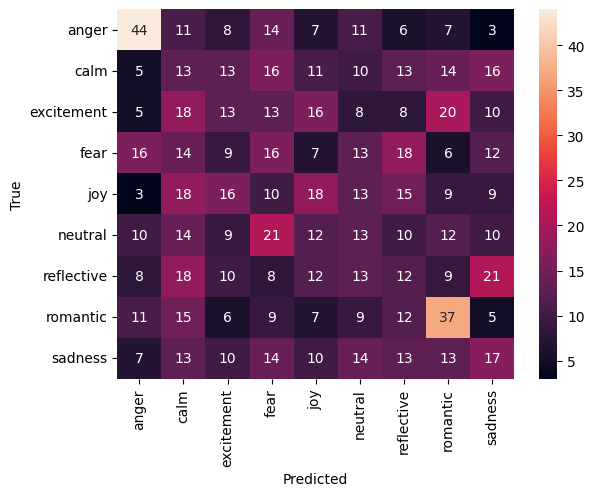

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()
